# Módulo 30 - K-Means
**Atividade:**

Nesta tarefa, vamos explorar o algoritmo de clustering K-means aplicado a um contexto diferente do usual. Em vez de segmentar perfis de viajantes ou clientes de e-commerce, vamos usar dados biológicos para segmentar diferentes espécies de pinguins com base em características físicas. Esta abordagem destaca a versatilidade do K-means para diversas áreas além de vendas e marketing.

A base de dados utilizada é a penguins do pacote seaborn, que contém informações sobre três espécies de pinguins: Adelie, Chinstrap e Gentoo. As variáveis disponíveis incluem medições físicas dos pinguins coletadas na Antártica.

species: Espécie do pinguim (Adelie, Chinstrap, Gentoo)

island: Ilha onde o pinguim foi observado (Biscoe, Dream, Torgersen)

bill_length_mm: Comprimento do bico em milímetros

bill_depth_mm: Profundidade do bico em milímetros

flipper_length_mm: Comprimento da barbatana em milímetros

body_mass_g: Massa corporal em gramas

sex: Sexo do pinguim (Male, Female)

year: Ano em que a observação foi feita

In [27]:
import plotly.express as px
import plotly.graph_objects as go
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import seaborn as sns

In [28]:
penguins = sns.load_dataset('penguins')

In [29]:
penguins

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
...,...,...,...,...,...,...,...
339,Gentoo,Biscoe,NaN,NaN,NaN,NaN,NaN
340,Gentoo,Biscoe,46.8,14.3,215.0,4850.0,Female
341,Gentoo,Biscoe,50.4,15.7,222.0,5750.0,Male
342,Gentoo,Biscoe,45.2,14.8,212.0,5200.0,Female


# 1 - Nesse exercício vocês devem verificar se temos variáveis missing, faltantes e excluir esses valores do dataset, também devem excluir as colunas com valores categóricos, que não utilizazam para o Kmeans.

In [30]:
penguins.drop_duplicates(inplace=True)

In [31]:
penguins.duplicated().sum()

np.int64(0)

In [32]:
penguins.isnull().sum()

species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
dtype: int64

In [33]:
penguins = penguins.dropna(subset=[
    'bill_length_mm',
    'bill_depth_mm',
    'flipper_length_mm',
    'body_mass_g',
    'sex'
])

In [34]:
penguins[['bill_length_mm',
      'bill_depth_mm',
      'flipper_length_mm',
      'body_mass_g','sex']].isnull().sum()

bill_length_mm       0
bill_depth_mm        0
flipper_length_mm    0
body_mass_g          0
sex                  0
dtype: int64

In [35]:
penguins['sex'] = penguins['sex'].map({
    'Female': 0,
    'Male': 1
})

In [36]:
penguins

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,1
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,0
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,0
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,0
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,1
...,...,...,...,...,...,...,...
338,Gentoo,Biscoe,47.2,13.7,214.0,4925.0,0
340,Gentoo,Biscoe,46.8,14.3,215.0,4850.0,0
341,Gentoo,Biscoe,50.4,15.7,222.0,5750.0,1
342,Gentoo,Biscoe,45.2,14.8,212.0,5200.0,0


In [37]:
penguins = penguins[['bill_length_mm',
                     'bill_depth_mm',
                     'flipper_length_mm',
                     'body_mass_g']]

In [38]:
penguins

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
0,39.1,18.7,181.0,3750.0
1,39.5,17.4,186.0,3800.0
2,40.3,18.0,195.0,3250.0
4,36.7,19.3,193.0,3450.0
5,39.3,20.6,190.0,3650.0
...,...,...,...,...
338,47.2,13.7,214.0,4925.0
340,46.8,14.3,215.0,4850.0
341,50.4,15.7,222.0,5750.0
342,45.2,14.8,212.0,5200.0


# 2 - Visualize a análise descritiva dos seus dados utilizando a função vista em aula pairplot. É possível já identificar possíveis agrupamentos? Se sim, quantos?

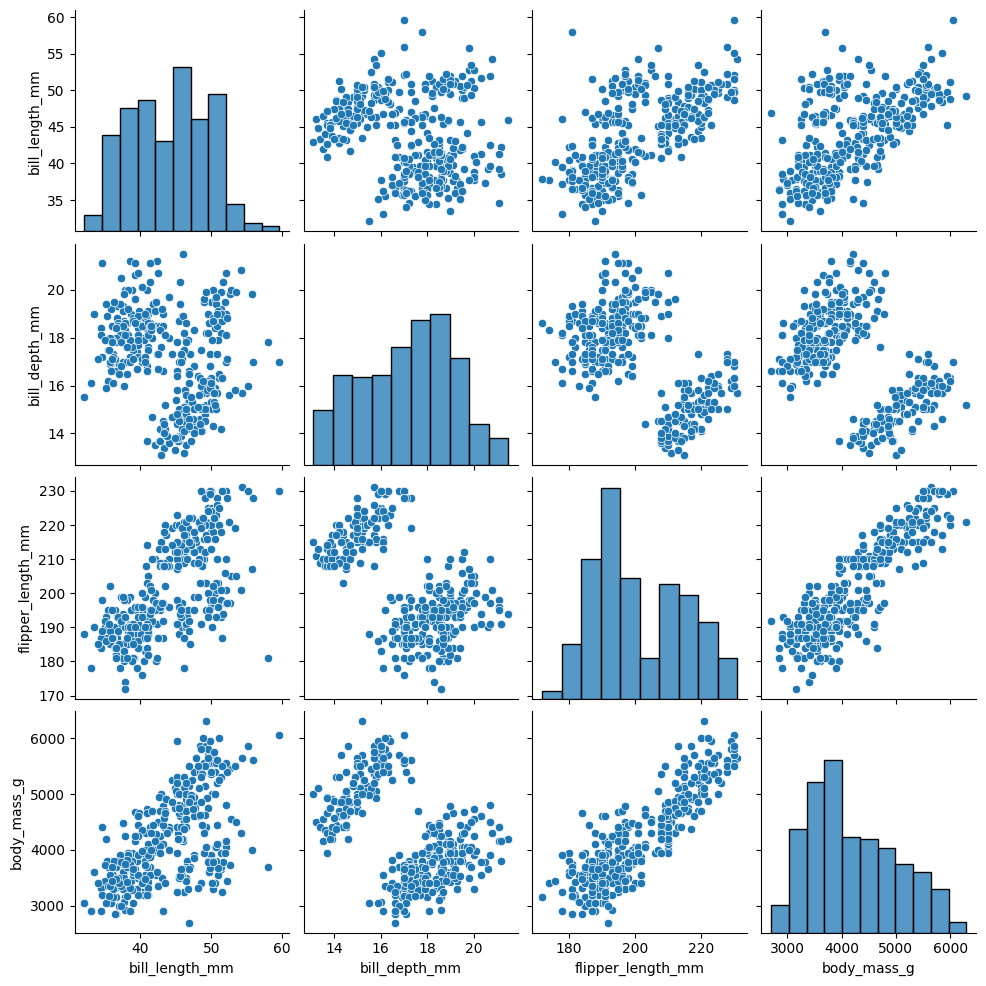

In [39]:
sns.pairplot(penguins)

A matriz de dispersão permite visualizar a distribuição de cada variável e também a relação entre cada par visualmente. Sim, é possível visualizar 3 agrupamentos o que é um bom indício já que são 3 espécies. Esses grupos são melhor identificados quanto olhamos para comprimento e profundidade do bico, comprimento da barbatana e massa corporal.

![Imagem](https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcRf2GhGWD4Us4hwK6-dcb4OLX9fUTQGXwO9Lz5zLd5fiQetCSKkJ67UgRRZ&s=10)

# 3 - Realize a padronização dos dados e visualize os dados.

In [41]:
base_padronizada = penguins.copy()
colunas_padronizadas = ['bill_length_mm',
                     'bill_depth_mm',
                     'flipper_length_mm',
                     'body_mass_g']
scaler = StandardScaler()
base_padronizada[colunas_padronizadas]=scaler.fit_transform(penguins[colunas_padronizadas])
base_padronizada



,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
0,-0.896042,0.780732,-1.426752,-0.568475
1,-0.822788,0.119584,-1.069474,-0.506286
2,-0.676280,0.424729,-0.426373,-1.190361
4,-1.335566,1.085877,-0.569284,-0.941606
5,-0.859415,1.747026,-0.783651,-0.692852
...,...,...,...,...
338,0.587352,-1.762145,0.931283,0.892957
340,0.514098,-1.457000,1.002739,0.799674
341,1.173384,-0.744994,1.502928,1.919069
342,0.221082,-1.202712,0.788372,1.234995


# 4 - Aplique o algoritmo do k means escolhendo o numero de clusters como igual a 3, que é que a quantidade de espécies que temos na base.

In [49]:
from sklearn.cluster import KMeans
Kmeans_perfil_penguins= KMeans(n_clusters = 3, n_init=10, random_state =42)
Kmeans_perfil_penguins.fit(base_padronizada)
centroides= Kmeans_perfil_penguins.cluster_centers_
centroides

array([[-1.04680889,  0.48662566, -0.88169491, -0.7627539 ],
       [ 0.65475809, -1.10270671,  1.16246305,  1.10121078],
       [ 0.67202511,  0.80526339, -0.28934658, -0.38410387]])

In [47]:
#removendo a padronização das variáveis para analisar melhor o centróides.
centroides_padronizados = Kmeans_perfil_penguins.cluster_centers_ #1 cria a nova variável
centroides_originais = scaler.inverse_transform(centroides_padronizados)
centroides_originais

array([[  38.27674419,   18.12170543,  188.62790698, 3593.79844961],
       [  47.56806723,   14.99663866,  217.23529412, 5092.43697479],
       [  47.66235294,   18.74823529,  196.91764706, 3898.23529412]])

In [57]:
penguins

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,cluster
0,39.1,18.7,181.0,3750.0,0
1,39.5,17.4,186.0,3800.0,0
2,40.3,18.0,195.0,3250.0,0
4,36.7,19.3,193.0,3450.0,0
5,39.3,20.6,190.0,3650.0,0
...,...,...,...,...,...
338,47.2,13.7,214.0,4925.0,1
340,46.8,14.3,215.0,4850.0,1
341,50.4,15.7,222.0,5750.0,1
342,45.2,14.8,212.0,5200.0,1


In [ ]:
#Esses centróides obtidos vão mostrar a média do cluster associada a esse centroide.     
#Médias por grupo: 
         #  bill_length_mm	bill_depth_mm	flipper_length_mm	body_mass_g
#Grupo 0:        38.27          18.12          188.62            3593.79
#Grupo 1:        47.56          14.99          217.23            5092.43
#Grupo 2:        47.66          18.74          196.91            3898.23


# 5 - Construa pelo 2 matriz de dispersão como realizada em aula indicando os pontos e centroides.

**Comece usando x='bill_length_mm' e y='bill_depth_mm' para analisar o primeiro gráfico e em seguida escolha outras variaveis para o segundo.**

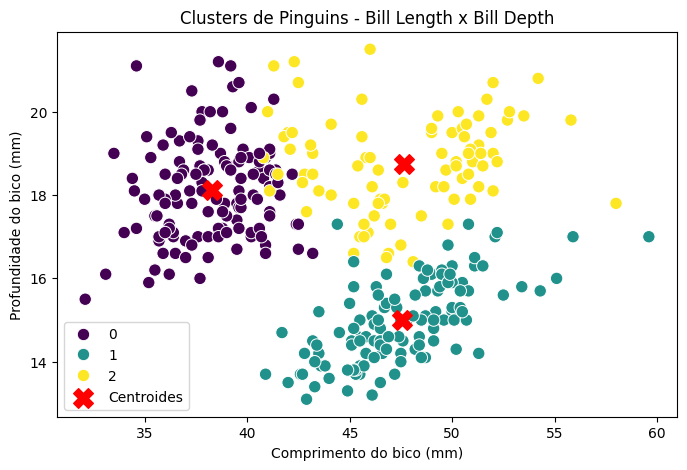

In [53]:
import matplotlib.pyplot as plt
penguins['cluster'] = Kmeans_perfil_penguins.labels_
plt.figure(figsize=(8,5))

# Pontos dos dados
sns.scatterplot(data=penguins,x='bill_length_mm', y='bill_depth_mm',hue='cluster',palette='viridis',s=80)

# Centroides
plt.scatter(centroides_originais[:, 0],  centroides_originais[:, 1],  c='red',marker='X',s=200,label='Centroides')

plt.title('Clusters de Pinguins - Bill Length x Bill Depth')
plt.xlabel('Comprimento do bico (mm)')
plt.ylabel('Profundidade do bico (mm)')
plt.legend()
plt.show()

O gráfico indica que:
O grupo 0 possui um comprimento de bico menor, mas uma profundidade maior.
O grupo 1 possui um comprimeto de bico maior que o 0. A profundidade do bico é em média menor que a do grupo 0 e 2.
O grupo 2 possui em média maior profundidade de bico e comprimento.

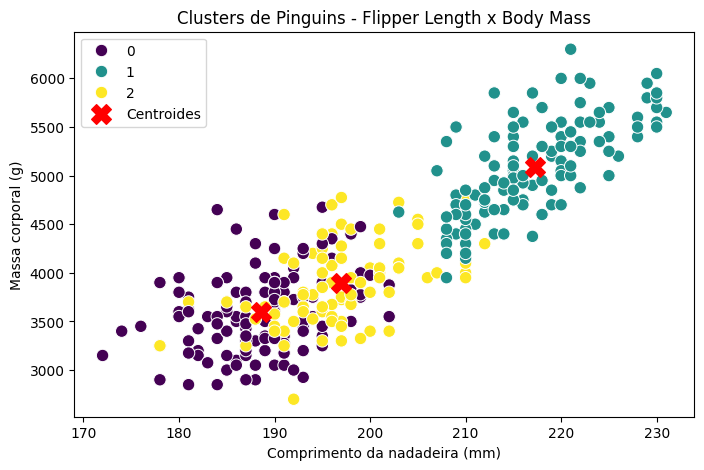

In [56]:
plt.figure(figsize=(8,5))

# Pontos
sns.scatterplot(data=penguins,x='flipper_length_mm',y='body_mass_g',hue='cluster',palette='viridis',s=80)

# Centroides
plt.scatter(centroides_originais[:, 2], centroides_originais[:, 3], c='red',marker='X',s=200,label='Centroides')

plt.title('Clusters de Pinguins - Flipper Length x Body Mass')
plt.xlabel('Comprimento da nadadeira (mm)')
plt.ylabel('Massa corporal (g)')
plt.legend()
plt.show()

O gráfico indica que com o aumento da nadadeira no grupo 1 é vista também uma maior massa corporal.
O grupo 1 possui em média maior comprimento de nadadeira e massa corporl.
o grupo 2 tem em média um comprimento de nadadeira maior e mais massa que o grupo 0, mas alguns indivíduos do grupo 2 se misturam com o grupo 0, mostrando que esses dois perfis possuem características físicas próximas. O grupo 0 representa indivíduos menores, enquanto o grupo 2 representa indivíduos com características intermediárias.

# 6 - Pesquise mais 3 utilidades de aplicações de algoritmos de clusterização e cite abaixo: 

Os algoritmos de clusterização são ferramentas muito úteis para a identificação e agrupamento de dados com características semelhantes. Essa capacidade permite sua aplicação em diversos segmentos. Neste exercício, a técnica foi utilizada para agrupar os pinguins de acordo com suas características físicas, identificando padrões e semelhanças entre as espécies.Além disso, a clusterização pode ser aplicada em diferentes áreas, como em sistemas de recomendação de filmes, músicas e livros para clientes de marketplaces, na identificação de comportamentos incomuns que podem indicar possíveis fraudes e também na área médica, auxiliando na detecção de padrões em exames de imagens e contribuindo para análises mais eficientes.

Olá Regina , boa noite.

Você trabalhou bem com o algoritmo K-Means e de sua aplicação em um conjunto de dados biológicos, explorando características físicas do pinguins. A sua forma como você preparou os dados, removendo valores ausentes e selecionando as variáveis numéricas adequadas, mostra que você está aplicando os passos corretos do fluxo de trabalho de um cientista de dados. Além disso sua execução da modelagem e a geração das visualizações com graficos de dispersão completam muito bem a tarefa. Sendo que seu código limpa os valores ausentes, remove colunas categóricas irrelevantes para o agrupamento, padroniza as variáveis numéricas e aplica o modelo K-Means definindo três clusters.

Dicas de melhoria

No seu fluxo, embora o objeto `StandardScaler` tenha sido importado, o código não aplicou a transformação de escala antes de rodar o K-Means. Como o K-Means utiliza distâncias euclidianas, variáveis com escalas maiores (como a massa corporal em gramas) acabam dominando o cálculo dos agrupamentos em relação às variáveis menores (como as medidas do bico em milímetros).
Para justificar a escolha de três clusters de forma técnica, seria muito interessante incluir o gráfico do método do cotovelo. Isso demonstra analiticamente o porquê de o número três ser o ideal para a base analisada.
Como você importou a biblioteca Plotly Express logo no início do código, poderia aproveitar o potencial dela para criar gráficos de dispersão interativos. Isso facilitaria a visualização dos centroides e a inspeção.
Como a base de pinguins original possui a coluna com as espécies reais, uma excelente prática de validação seria comparar os clusters gerados pelo K-Means não supervisionado com as espécies verdadeiras usando uma matriz de confusão ou um gráfico com cores reais, avaliando a acurácia do agrupamento.
Na seção final sobre as utilidades adicionais da clusterização, procure detalhar um pouco mais cada caso de uso prático (como segmentação de imagens, detecção de fraudes ou análise de expressão gênica), explicando o motivo pelo qual o agrupamento se aplica a esses cenários.
Obs.: As dicas e sugestões não caracterizam a nota final da tarefa, são apenas para melhorar o desenvolvimento do seu trabalho ao longo do curso e na carreira profissional.

Conte comigo

Um abraço

Rodrigo